In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap



scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

sessions = ['Achilles_10252013','Buddy_06272013','Cicero_09012014','Gatsby_08022013','Achilles_11012013','Cicero_09102014','Cicero_09172014','Gatsby_08282013']

rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [27]:

output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['state'] = []
output_dict['shank'] = []
output_dict['ripple_length'] = []
output_dict['ripple_counts'] = []
output_dict['ripple_max_amp'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

states = ['pre','post']
for session in sessions[0:1]:

    print(session)
    logging.info('session = ' + str(session))
    
    all_shanks,left_shanks,right_shanks = hc11_bf.get_shanks_info(session)
    LFP,srate,SWS,SWS_lfp_index,SWS_lfp_index_pre,SWS_lfp_index_pos = hc11_bf.load_lfp_hc11_data(session)
    # spike_times,spike_ids,pyr_ids,int_ids = hc11_bf.load_spikes_hc11_data(RatName)
        
    os.chdir(scripts_path)
    all_shanks_electrode_position = np.load(f'electrode_position_{session}.npy')

    all_shanks_distance_to_ref = np.arange(0,(len(all_shanks)/2)*200,200)
    all_shanks_distance_to_ref = np.concatenate([all_shanks_distance_to_ref,all_shanks_distance_to_ref])
    accepted_shanks = np.setdiff1d(np.arange(len(all_shanks)),rejected_shanks[session])

    for state in states[0:1]:
        if state == 'pre':
            # lfp_index = SWS_lfp_index_pre[-int(30*60*srate):]
            lfp_index = SWS_lfp_index_pre[0:int(30*60*srate)]
        elif state == 'post':
            lfp_index = SWS_lfp_index_pos[0:int(30*60*srate)]
                
        for shank_1_idx in [0]:
        # for shank_1_idx in np.arange(0,len(accepted_shanks)):    
            
            shank_1 = accepted_shanks[shank_1_idx]
            print('Shank 1 = ' + str(shank_1))
    
    
            Imaxripple = np.where(all_shanks_electrode_position[shank_1]==0)[0][0]
            shanks = all_shanks[shank_1]
            ripple_lfp_1 = LFP[shanks[Imaxripple],lfp_index].copy()
                
            ripple_features = ripple.get_ripple_info(ripple_lfp_1, srate, ripple_band=(100, 250),ripple_threshold_level = 2, 
                                             min_ripple_duration = 0.02, max_ripple_duration = 0.2, smooth_time = 0.005)
            
            ripple_length = []
            for cyc in ripple_features['cycles']:
                ripple_length.append(cyc.shape[0]/srate)
            ripple_length = np.nanmean(ripple_length)
            ripple_counts = len(ripple_features['centers'])
            ripple_max_amp = np.nanmean(ripple_features['max_amplitudes'])
    

            output_dict['rat'].append(session[0:3])
            output_dict['session'].append(session)
            output_dict['state'].append(state)
            output_dict['shank'].append(shank_1)
            output_dict['ripple_length'].append(ripple_length)
            output_dict['ripple_counts'].append(ripple_counts)
            output_dict['ripple_max_amp'].append(ripple_max_amp)

df = pd.DataFrame(output_dict)
df


Achilles_10252013
Shank 1 = 0


,rat,session,state,shank,ripple_length,ripple_counts,ripple_max_amp
0,Ach,Achilles_10252013,pre,0,0.05314,1258,766.646003


In [ ]:

bins_dt = 30*60
time_bins=np.arange(0,1800+bins_dt,bins_dt)
bins_centers = time_bins[0:-1] + bins_dt/2

ripple_ts = np.array(ripple_features['centers'])/srate
ripple_max_amplitudes = np.array(ripple_features['max_amplitudes'])

ripple_mean_amp = []
ripple_mean_count = []
for rr in range(len(time_bins)-1):
    
    aux = (ripple_ts >= time_bins[rr]) & (ripple_ts <= time_bins[rr+1])
    ripple_mean_count.append(np.sum(aux))
    ripple_mean_amp.append(np.nanmean(ripple_max_amplitudes[aux]))
ripple_mean_amp = np.array(ripple_mean_amp)
ripple_mean_count = np.array(ripple_mean_count)

plt.figure()
plt.plot(bins_centers,ripple_mean_count,'k')
plt.show()

plt.figure()
plt.plot(bins_centers,ripple_mean_amp,'k')
plt.show()


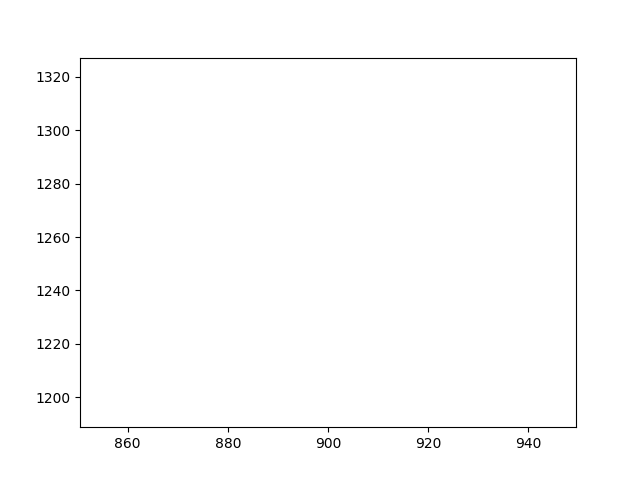

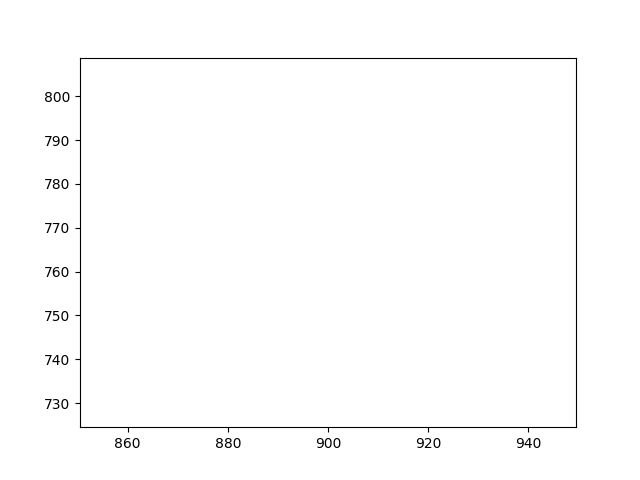

In [30]:

bins_dt = 30*60
time_bins=np.arange(0,1800+bins_dt,bins_dt)
bins_centers = time_bins[0:-1] + bins_dt/2

ripple_ts = np.array(ripple_features['centers'])/srate
ripple_max_amplitudes = np.array(ripple_features['max_amplitudes'])

ripple_mean_amp = []
ripple_mean_count = []
for rr in range(len(time_bins)-1):
    
    aux = (ripple_ts >= time_bins[rr]) & (ripple_ts <= time_bins[rr+1])
    ripple_mean_count.append(np.sum(aux))
    ripple_mean_amp.append(np.nanmean(ripple_max_amplitudes[aux]))
ripple_mean_amp = np.array(ripple_mean_amp)
ripple_mean_count = np.array(ripple_mean_count)

plt.figure()
plt.plot(bins_centers,ripple_mean_count,'k')
plt.show()

plt.figure()
plt.plot(bins_centers,ripple_mean_amp,'k')
plt.show()


/tmp/ipykernel_8238/3723740988.py:14: RuntimeWarning: Mean of empty slice
  ripple_mean_amp.append(np.nanmean(ripple_max_amplitudes[aux]))


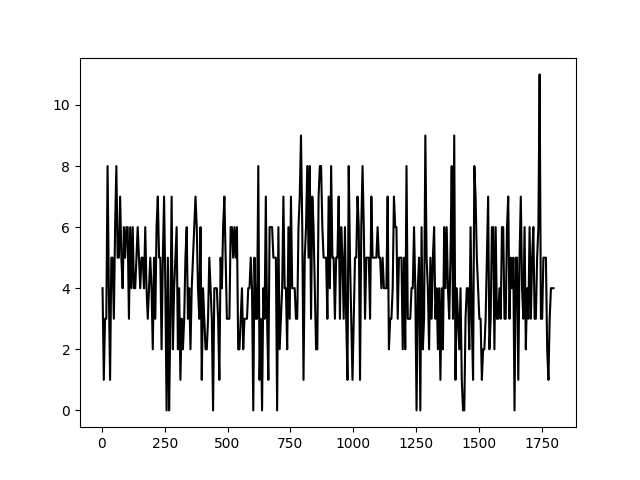

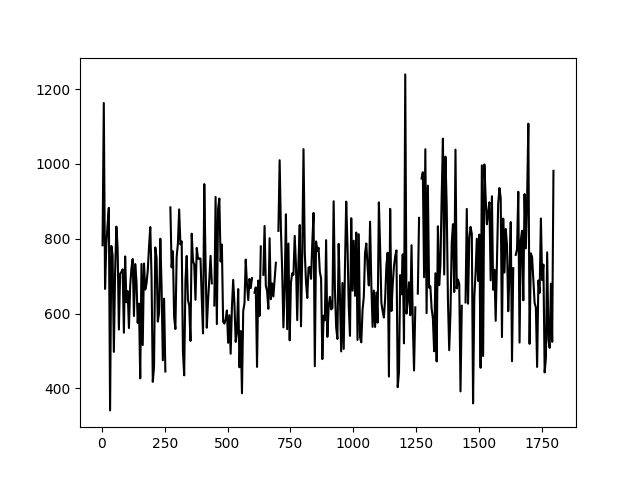

In [26]:

bins_dt = 5
time_bins=np.arange(0,1800+bins_dt,bins_dt)
bins_centers = time_bins[0:-1] + bins_dt/2

ripple_ts = np.array(ripple_features['centers'])/srate
ripple_max_amplitudes = np.array(ripple_features['max_amplitudes'])

ripple_mean_amp = []
ripple_mean_count = []
for rr in range(len(time_bins)-1):
    
    aux = (ripple_ts >= time_bins[rr]) & (ripple_ts <= time_bins[rr+1])
    ripple_mean_count.append(np.sum(aux))
    ripple_mean_amp.append(np.nanmean(ripple_max_amplitudes[aux]))
ripple_mean_amp = np.array(ripple_mean_amp)
ripple_mean_count = np.array(ripple_mean_count)

plt.figure()
plt.plot(bins_centers,ripple_mean_count,'k')
plt.show()

plt.figure()
plt.plot(bins_centers,ripple_mean_amp,'k')
plt.show()


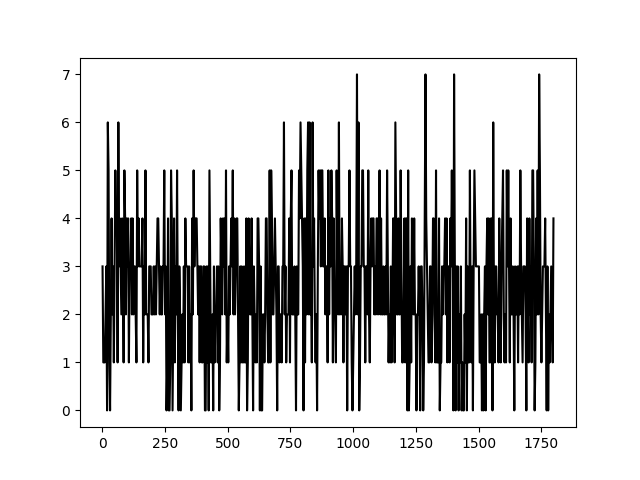

In [23]:
bins_dt = 3
counts, bins_edges = np.histogram(np.array(ripple_features['centers'])/srate,bins=np.arange(0,1800+bins_dt,bins_dt))
bins_centers = bins_edges[0:-1] + bins_dt/2

plt.figure()
plt.plot(bins_centers,counts,'k')
plt.show()


In [6]:
bins_dt = 10
counts, bins_edges = np.histogram(np.array(ripple_features['centers'])/srate,bins=np.arange(0,1800+bins_dt,bins_dt))
bins_centers = bins_edges[0:-1] + bins_dt/2

plt.figure()
plt.plot(bins_centers,counts,'k')
plt.show()


1800

In [12]:
ripple_features.keys()
ripple_max_amp

np.float64(766.6460031145891)

In [3]:
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_AmpAmpCoupling_WholeSignal_PrePost.csv',index=False)


In [3]:
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

filename = 'Figure_Ripple_AmpAmpCoupling_WholeSignal_PrePost.csv'
df = pd.read_csv(filename)

# Set reference categories
# df['side'] = pd.Categorical(df['side'], categories=['ipsi', 'contra'], ordered=True)
# df['state'] = pd.Categorical(df['state'], categories=['pre', 'post'], ordered=True)
df


,rat,session,side,state,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.856126,3.040880,0.983945,0.0,0.000366
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.824979,4.194897,0.971639,0.0,0.000473
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.796551,7.845323,0.958331,0.0,0.000560
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.714414,10.774275,0.946081,0.0,0.000577
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.685440,12.846040,0.932308,0.0,0.000627
...,...,...,...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,1.377306,-9.893647,0.954591,0.0,0.001013
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.720612,8.447304,0.899948,0.0,0.000823
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,1.218413,-6.740792,0.967035,0.0,0.000756
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.634193,10.255005,0.906980,0.0,0.000694


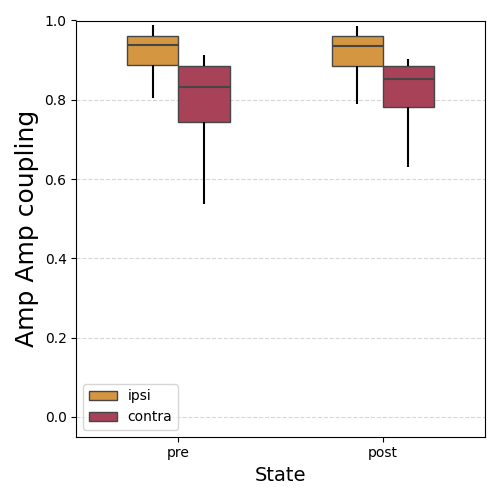

In [4]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#               hue_order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="state",order = ['pre','post'], y="r_value", hue='side',
            hue_order=['ipsi','contra'], showfliers=False, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#                 hue_order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Amp Amp coupling',fontsize=18)
plt.xlabel('State',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

# os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fi_name)

